In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Carica i file
df_geni = pd.read_csv("../data/clinical.project-tcga-brca/TCGA.BRCA.sampleMap_HiSeqV2/HiSeqV2", sep="\t", header=0)
df_pheno = pd.read_csv("../data/clinical.project-tcga-brca/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", sep="\t")

# Imposta 'sample' come indice del file genico (i nomi dei geni diventano l'indice)
df_geni = df_geni.set_index('sample')

# Trasponi: ora righe = campioni, colonne = geni
df_geni = df_geni.T

# Pulisci gli ID campione del file genico (es. TCGA-AR-A5QQ-01 → TCGA-AR-A5QQ)
df_geni.index = ['-'.join(id.split('-')[:3]) for id in df_geni.index]

# Pulisci gli ID del file fenotipi
df_pheno['patient_id'] = ['-'.join(id.split('-')[:3]) for id in df_pheno['sampleID']]
df_pheno = df_pheno.set_index('patient_id')

# Crea variabile evento (1 = morto, 0 = vivo)
df_pheno['event'] = df_pheno['Days_to_date_of_Death_nature2012'].notna().astype(int)

# Merge
df_merged = df_geni.join(df_pheno[['event', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 
                                    'AJCC_Stage_nature2012']], how='inner')

# Rimuovi NaN sulla colonna event
df_merged = df_merged.dropna(subset=['event'])

print("Shape dopo merge:", df_merged.shape)
print("Distribuzione evento:", df_merged['event'].value_counts())

Shape dopo merge: (1492, 20533)
Distribuzione evento: event
0    1274
1     218
Name: count, dtype: int64


In [4]:
# Target
y = df_merged['event']

# Features: solo colonne numeriche
X = df_merged.select_dtypes(include=[np.number])

# Rimuovi la colonna event dalle features
X = X.drop(columns=['event'])

# Rimuovi anche le colonne cliniche (non vogliamo che il modello "bara" usando l'età o lo stage)
cols_to_drop = ['Age_at_Initial_Pathologic_Diagnosis_nature2012', 'AJCC_Stage_nature2012']
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribuzione target:")
print(y.value_counts())
print(f"\nClass imbalance: {y.mean():.1%} positive (deceased)")

Shape X: (1492, 20530)
Shape y: (1492,)

Distribuzione target:
event
0    1274
1     218
Name: count, dtype: int64

Class imbalance: 14.6% positive (deceased)


In [5]:
from sklearn.preprocessing import StandardScaler

# Scala le features (necessario per LASSO)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LASSO con cross-validation per trovare il miglior alpha
print("Fitting LassoCV... (potrebbe richiedere qualche minuto)")
lasso = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_scaled, y)

# Trova i geni con coefficiente != 0
coef_df = pd.DataFrame({'gene': X.columns, 'coef': lasso.coef_})
important_genes = coef_df[coef_df['coef'] != 0]['gene'].tolist()

print(f"LASSO ha selezionato {len(important_genes)} geni su {len(X.columns)} totali.")
print(f"Alpha ottimale: {lasso.alpha_:.4f}")

Fitting LassoCV... (potrebbe richiedere qualche minuto)
LASSO ha selezionato 162 geni su 20530 totali.
Alpha ottimale: 0.0188


In [6]:
# Reduced dataset 
X_reduced = X[important_genes]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribuzione classi nel training set:")
print(y_train.value_counts())

# Random Forest
print("\nFitting Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Done!")

Training set: (1193, 162)
Test set: (299, 162)

Distribuzione classi nel training set:
event
0    1019
1     174
Name: count, dtype: int64

Fitting Random Forest...
Done!


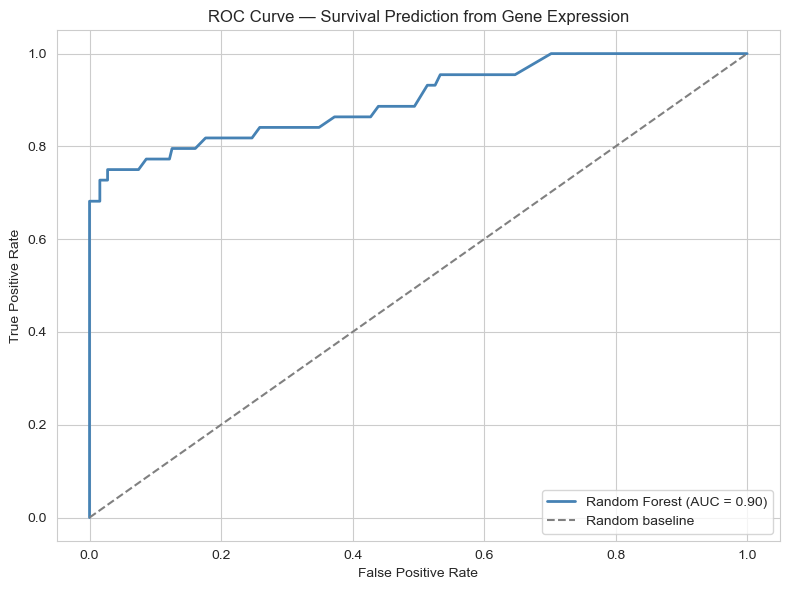

AUC: 0.901


In [7]:
# Predict the probabilities on the test set
y_probs = rf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_probs)

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Survival Prediction from Gene Expression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/plots/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC: {auc:.3f}")

C:\Users\Santi\AppData\Local\Temp\ipykernel_18724\3852066501.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='importance', y='gene', palette='Blues_r')


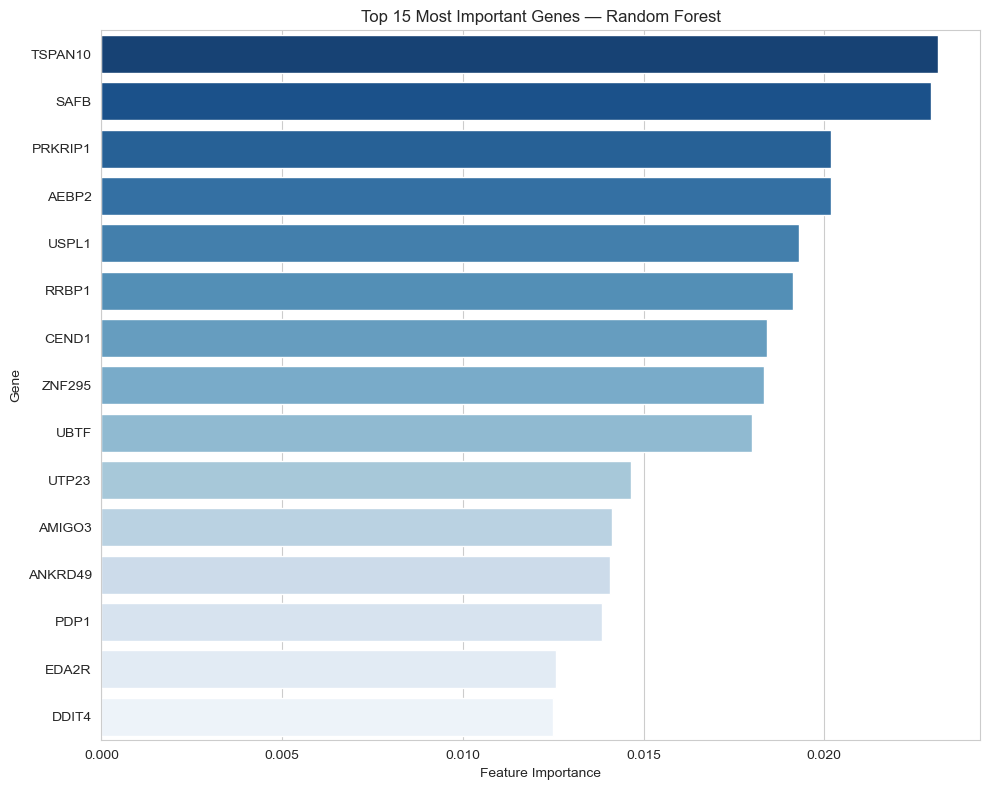

Top 15 Most Important Genes:
   gene  importance
TSPAN10    0.023150
   SAFB    0.022959
PRKRIP1    0.020199
  AEBP2    0.020189
  USPL1    0.019292
  RRBP1    0.019142
  CEND1    0.018403
 ZNF295    0.018332
   UBTF    0.017998
  UTP23    0.014656
 AMIGO3    0.014115
ANKRD49    0.014080
   PDP1    0.013840
  EDA2R    0.012565
  DDIT4    0.012504


In [8]:
# Create DataFrame with Imports
importances = pd.DataFrame({
    'gene': X_reduced.columns,
    'importance': rf.feature_importances_
})
importances = importances.sort_values(by='importance', ascending=False)

# Plot of the top 15 most important genes
plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='importance', y='gene', palette='Blues_r')
plt.title('Top 15 Most Important Genes — Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Gene')
plt.tight_layout()
plt.savefig('../results/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 Most Important Genes:")
print(importances.head(15).to_string(index=False))

## ML Survival Prediction from Gene Expression

This notebook extends the clinical analysis with a machine learning approach: predicting patient survival (deceased vs alive) directly from gene expression profiles using a two-step pipeline and LASSO feature selection followed by Random Forest classification.

### Dataset
- **Gene expression**: TCGA-BRCA HiSeq V2 (20,530 genes, log2-normalized)
- **Phenotype**: Xena TCGA-BRCA clinical annotations
- **Final cohort after merge**: 1,492 patients (1,274 alive, 218 deceased — 14.6% positive class)

### Step 1: LASSO Feature Selection
LassoCV (5-fold CV) reduced the feature space from 20,530 to **162 genes** (alpha = 0.0188), retaining only genes with non-zero coefficients and therefore genuine predictive signal for survival outcome.

### Step 2: Random Forest Classification
A Random Forest (500 trees, class_weight='balanced' to handle class imbalance) was trained on the 162 LASSO-selected genes using an 80/20 stratified train/test split.

### Results

**ROC-AUC: 0.901** — the model discriminates between deceased and alive patients with high accuracy using gene expression data alone, well above the 0.80 threshold considered strong for clinical prediction tasks.

### Top 15 Predictive Genes

| Gene | Importance |
|------|-----------|
| TSPAN10 | 0.0232 |
| SAFB | 0.0230 |
| PRKRIP1 | 0.0202 |
| AEBP2 | 0.0202 |
| USPL1 | 0.0193 |
| RRBP1 | 0.0191 |
| CEND1 | 0.0184 |
| ZNF295 | 0.0183 |
| UBTF | 0.0180 |
| UTP23 | 0.0147 |
| AMIGO3 | 0.0141 |
| ANKRD49 | 0.0141 |
| PDP1 | 0.0138 |
| EDA2R | 0.0126 |
| DDIT4 | 0.0125 |

Several of these genes have known relevance in cancer biology:
- **EDA2R** and **DDIT4** are stress-response genes linked to apoptosis and cellular stress pathways
- **UBTF** is involved in ribosomal RNA transcription, frequently dysregulated in cancer
- **AEBP2** is a Polycomb complex component associated with epigenetic regulation in breast cancer

### Summary
This analysis demonstrates that gene expression profiles alone carry substantial prognostic information for breast cancer survival. The LASSO + Random Forest pipeline successfully reduced dimensionality from 20,530 to 162 informative genes while achieving AUC = 0.901, providing a solid foundation for more advanced predictive modeling (e.g. deep learning, multi-omics integration).